In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset=pd.read_csv("Mall_Customers.csv")

In [3]:
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
X=dataset.iloc[:,[3,4]].values

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

C:\Users\lenovo\anaconda3\envs\aiml\lib\site-packages\sklearn\utils\validation.py:179: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(joblib_version) < '0.12':


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   BIRCH_Cluster  
0              3  
1              4  
2              3  
3              4  
4              3  
1    109
0     36
3     25
4     22
2      8
Name: BIRCH_Cluster, dtype: int64


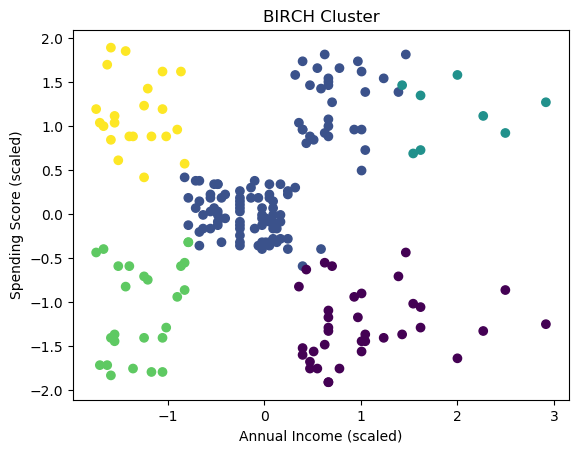

In [6]:
from sklearn.cluster import Birch
birch = Birch(n_clusters=5)   
clusters = birch.fit_predict(X_scaled)
dataset['BIRCH_Cluster'] = clusters
print(dataset.head())
print(dataset['BIRCH_Cluster'].value_counts())
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("BIRCH Cluster")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

In [7]:
dataset.groupby('BIRCH_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
BIRCH_Cluster,,
0,87.750000,17.583333
1,62.394495,59.256881
2,112.625000,79.625000
3,27.400000,22.600000
4,25.727273,79.363636
